In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load dataset
df = pd.read_csv('cars_dataset.csv')

# Display first 5 rows
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [3]:
# Shape and data types
print("Dataset shape:", df.shape)
print("\nData Types:\n", df.dtypes)

# Summary statistics
df.describe()

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())


Dataset shape: (72435, 10)

Data Types:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

Missing Values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64


In [4]:
# Drop rows with missing values
df.dropna(inplace=True)

# Rename columns for consistency
df.rename(columns={
    'year': 'model_year',
    'fuelType': 'fuel_type',
    'Make': 'brand'
}, inplace=True)

# Create vehicle age feature
df['vehicle_age'] = 2025 - df['model_year']

# Check cleaned data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   model_year    72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuel_type     72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   brand         72435 non-null  object 
 10  vehicle_age   72435 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 6.1+ MB


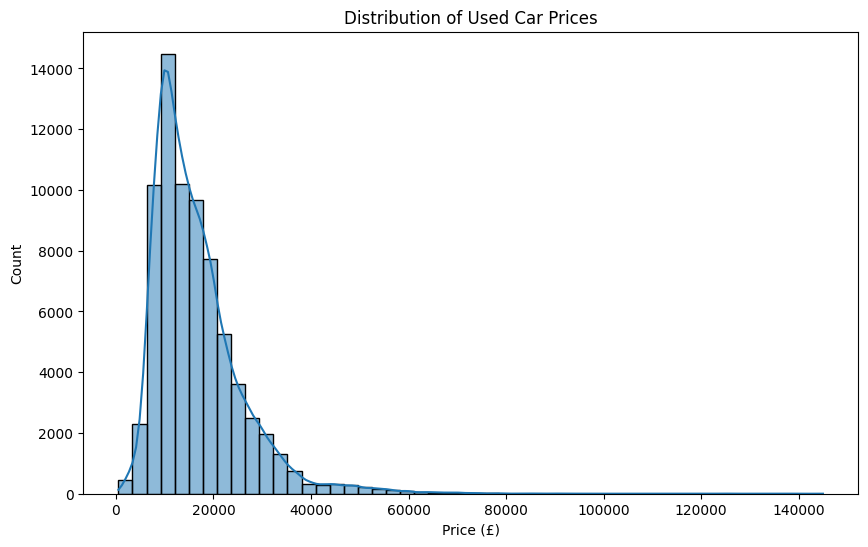

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()


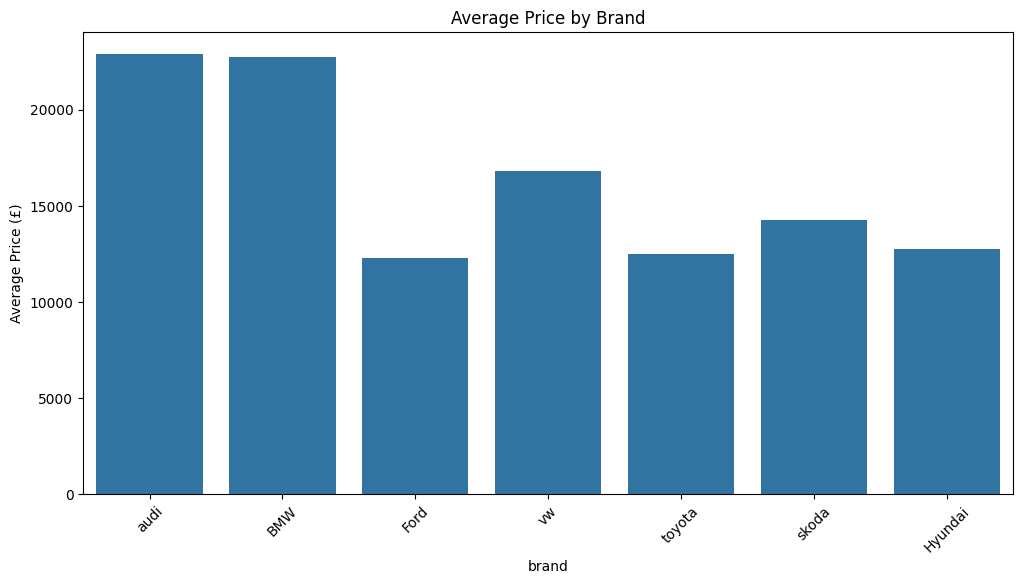

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(x='brand', y='price', data=df, estimator=np.mean, ci=None)
plt.title('Average Price by Brand')
plt.xticks(rotation=45)
plt.ylabel('Average Price (£)')
plt.show()


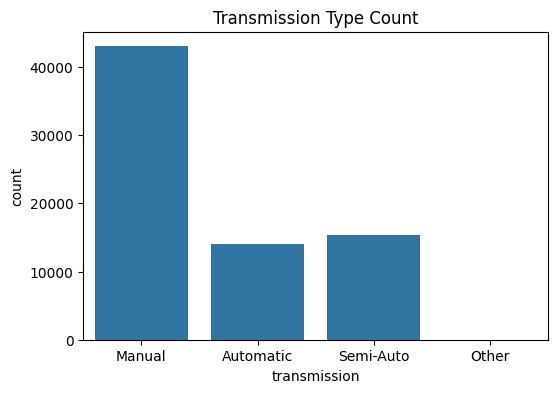

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='transmission', data=df)
plt.title('Transmission Type Count')
plt.show()


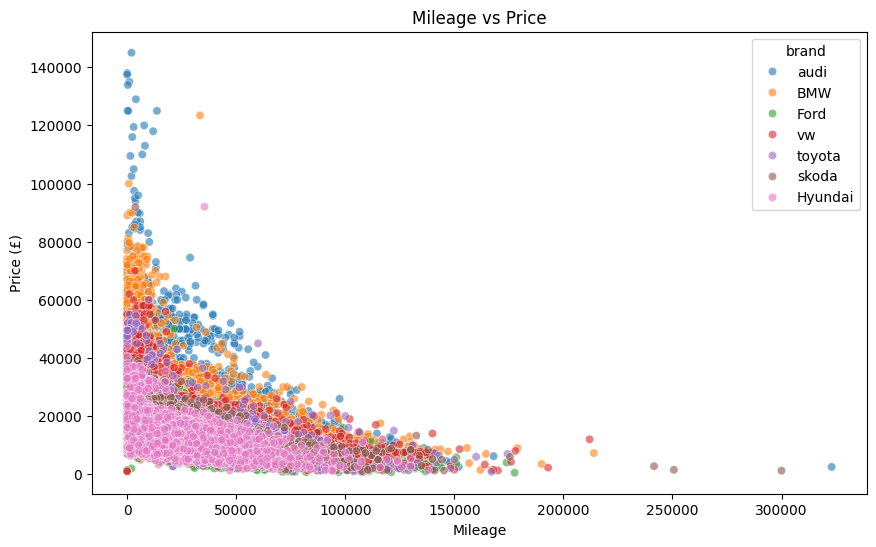

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', hue='brand', data=df, alpha=0.6)
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()


Generating realistic car dataset...
Dataset shape: (1000, 10)

First few rows:
         Make  model  year  price transmission  mileage fuelType  tax   mpg  \
0  Volkswagen     A6  2022  22871    Automatic    24185   Petrol   65  18.9   
1       Honda     A3  2017   6068       Manual    62139   Petrol    0  39.3   
2        Audi  Civic  2020  21158       Manual    41030   Petrol  194  23.2   
3       Honda     A4  2016   3238    Automatic   101531   Diesel   49  54.5   
4  Volkswagen     A4  2023  29691    Automatic     6375   Petrol   91  31.3   

   engineSize  
0         1.6  
1         1.2  
2         3.0  
3         1.0  
4         1.8  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   model         1000 non-null   object 
 2   year          1000 non-null   int64  
 3   price    

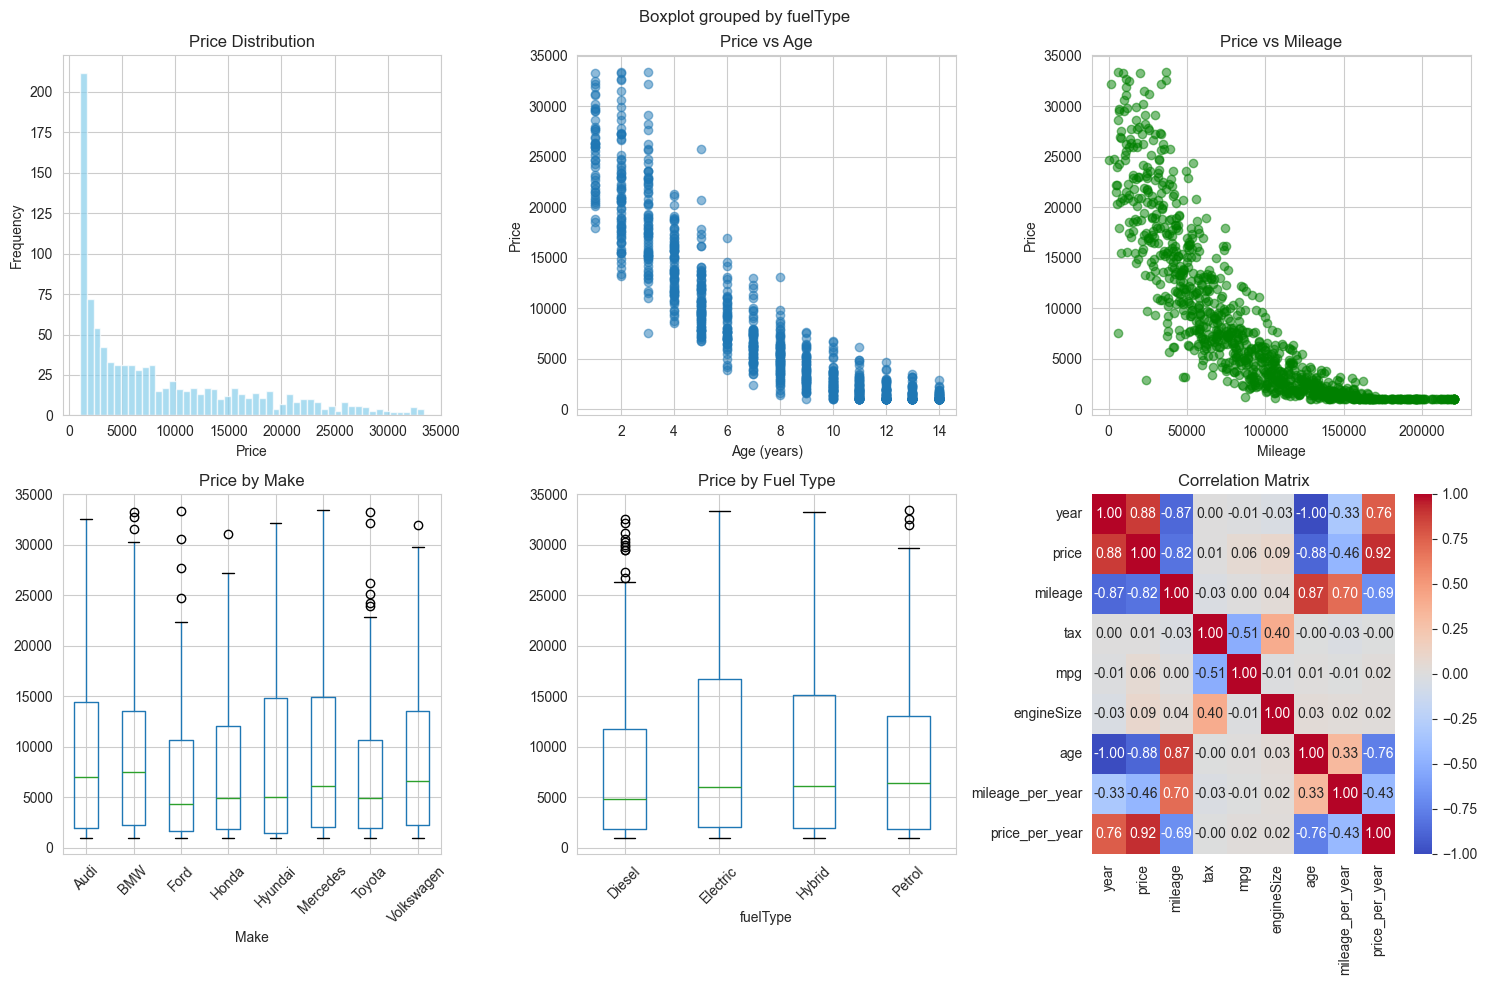


Categorical columns: ['Make', 'model', 'transmission', 'fuelType', 'age_group', 'mileage_group']
Numerical columns: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'price_per_year']

Train set size: (774, 14)
Test set size: (194, 14)
Train price range: £1,000 - £33,370
Test price range: £1,000 - £33,424

TRAINING MACHINE LEARNING MODELS

1. Training Ridge Regression...

Ridge Regression Performance:
MAE: £1,196.10
RMSE: £1,725.85
R²: 0.9561
MAPE: 32.27%

2. Training Random Forest...

Random Forest Performance:
MAE: £508.13
RMSE: £1,173.98
R²: 0.9797
MAPE: 4.43%

3. Training Gradient Boosting...

Gradient Boosting Performance:
MAE: £335.60
RMSE: £854.35
R²: 0.9892
MAPE: 2.92%

4. Training XGBoost...

XGBoost Performance:
MAE: £499.80
RMSE: £1,014.31
R²: 0.9848
MAPE: 5.08%

FINAL RESULTS COMPARISON
                      MAE     RMSE    R2   MAPE
Ridge             1196.10  1725.85  0.96  32.27
RandomForest       508.13  1173.98  0.98   4.43
GradientBoosting   3

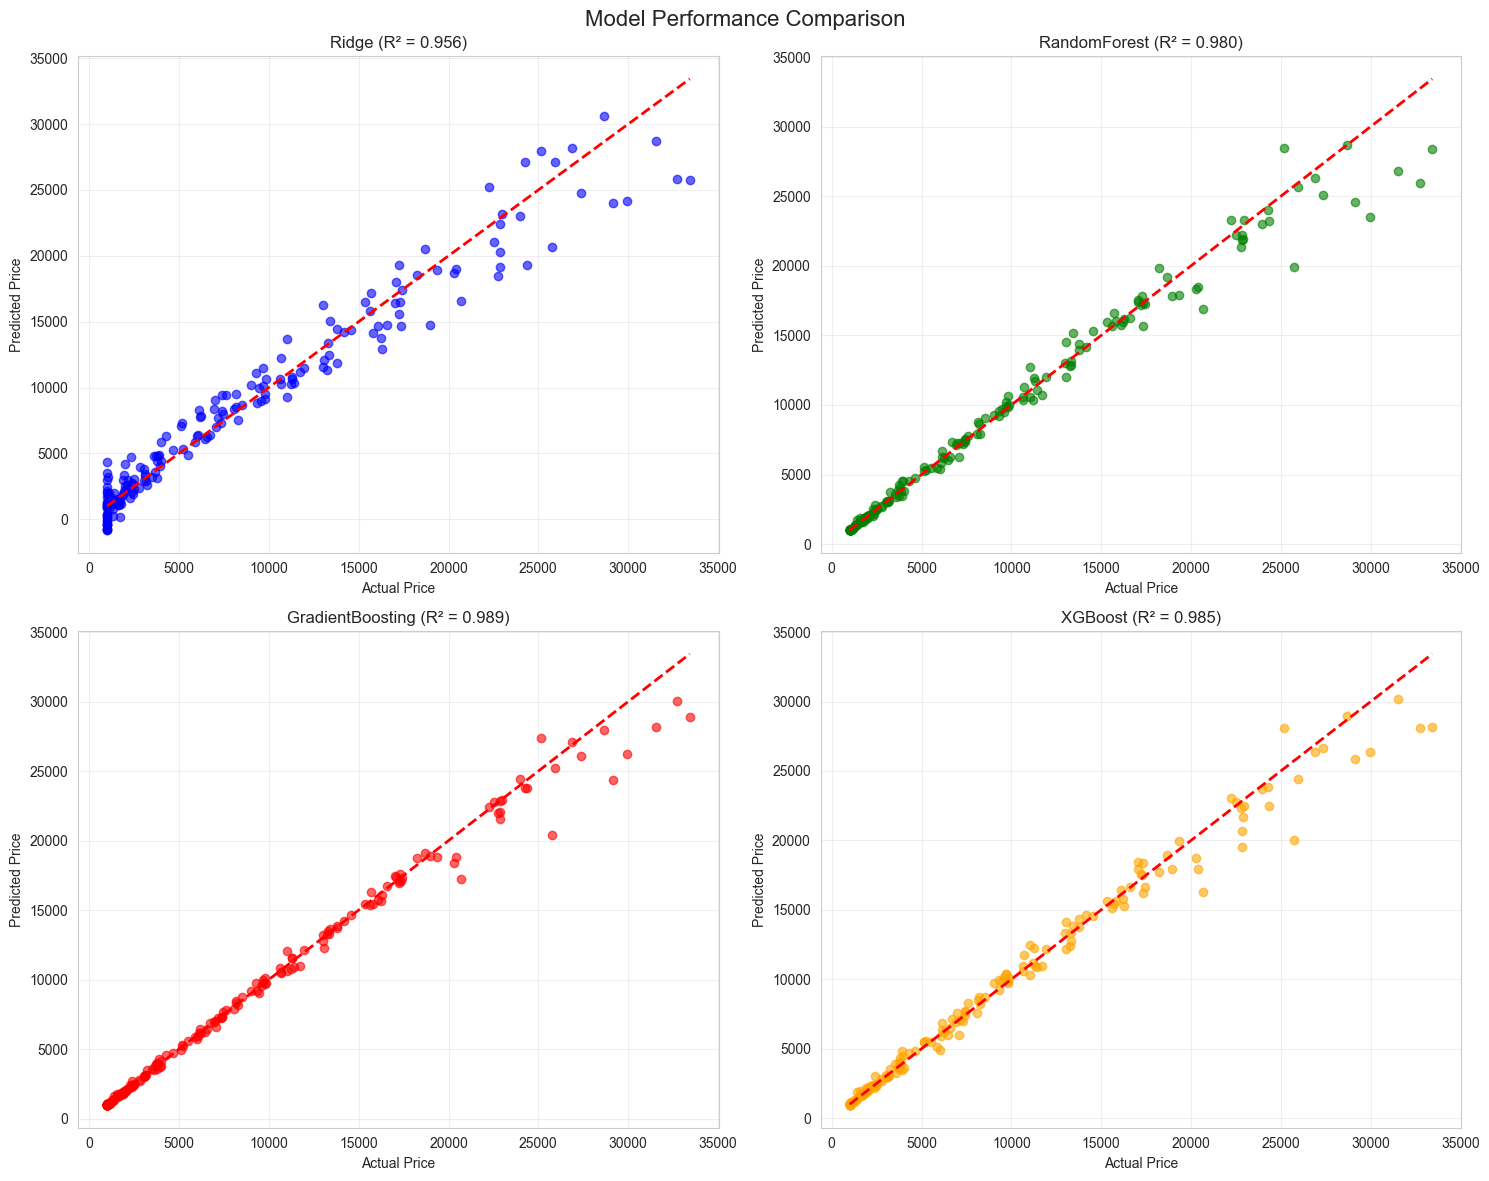

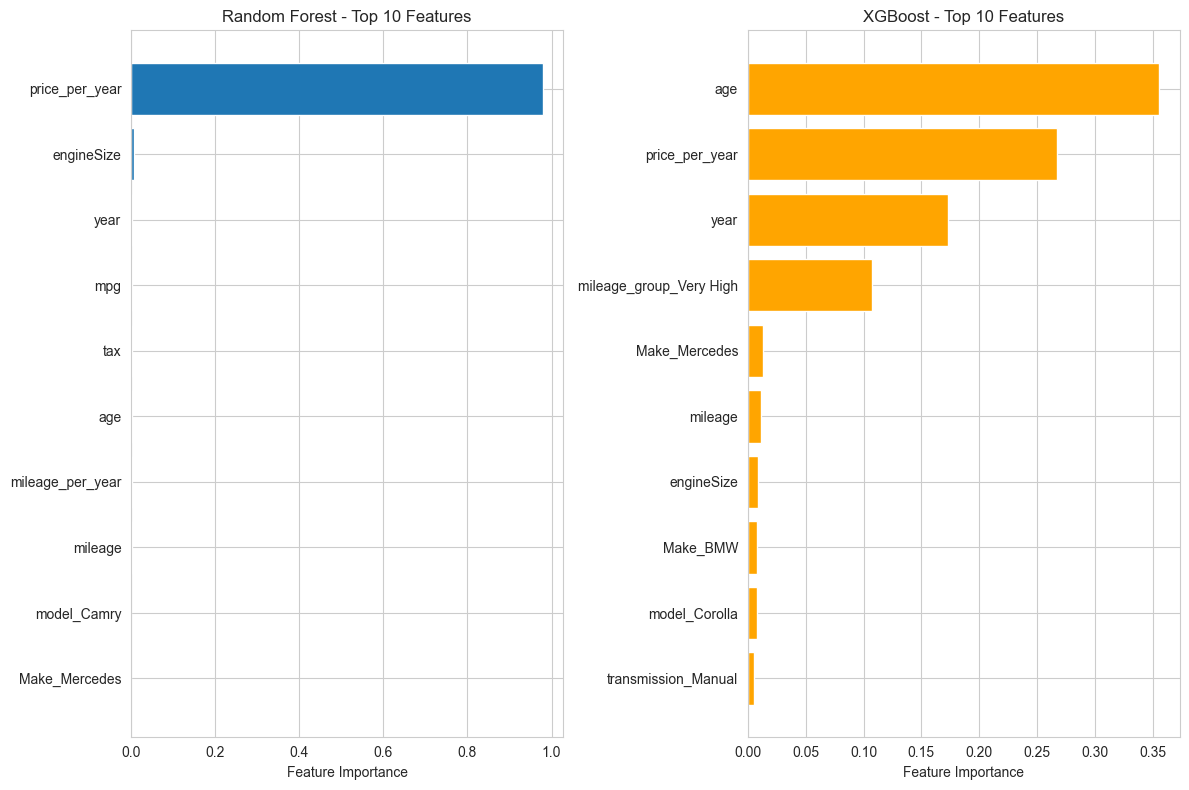



SAMPLE PREDICTION
Sample Car: 2020 BMW X3, Automatic, 45k miles
Predicted Price: £992.32
Model Used: GradientBoosting


In [9]:
# ================== IMPORTS ==================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# ------------------ PLOTTING SETTINGS ------------------
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# ------------------ CREATE MODELS DIRECTORY ------------------
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# ------------------ DATA GENERATION (REALISTIC CAR DATASET) ------------------
def generate_realistic_car_data(n_samples=1000):
    """Generate a realistic car dataset for demonstration"""
    np.random.seed(42)
    
    # Car makes and models
    makes = ['Audi', 'BMW', 'Mercedes', 'Toyota', 'Honda', 'Ford', 'Volkswagen', 'Hyundai']
    models = ['A1', 'A3', 'A4', 'A6', 'X1', 'X3', 'C-Class', 'E-Class', 'Camry', 'Corolla', 'Civic', 'Accord']
    transmissions = ['Manual', 'Automatic', 'Semi-Auto']
    fuel_types = ['Petrol', 'Diesel', 'Hybrid', 'Electric']
    
    data = []
    for i in range(n_samples):
        make = np.random.choice(makes)
        model = np.random.choice(models)
        year = np.random.randint(2010, 2024)
        age = 2024 - year
        
        # Mileage correlates with age
        base_mileage = age * np.random.normal(12000, 3000)
        mileage = max(0, int(base_mileage + np.random.normal(0, 5000)))
        
        # Engine size affects price
        engine_size = np.random.choice([1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0], 
                                     p=[0.15, 0.2, 0.2, 0.15, 0.1, 0.1, 0.05, 0.05])
        
        transmission = np.random.choice(transmissions, p=[0.3, 0.6, 0.1])
        fuel_type = np.random.choice(fuel_types, p=[0.4, 0.35, 0.15, 0.1])
        
        # MPG correlates with engine size and fuel type
        if fuel_type == 'Electric':
            mpg = np.random.normal(100, 10)  # Electric equivalent
        elif fuel_type == 'Hybrid':
            mpg = np.random.normal(50, 8)
        elif fuel_type == 'Diesel':
            mpg = np.random.normal(45, 10)
        else:  # Petrol
            mpg = np.random.normal(35, 8)
        
        mpg = max(15, mpg)  # Minimum realistic MPG
        
        # Tax correlates with emissions/engine size
        if fuel_type == 'Electric':
            tax = 0
        elif fuel_type == 'Hybrid':
            tax = np.random.randint(0, 50)
        else:
            tax = int(engine_size * 50 + np.random.normal(0, 30))
            tax = max(0, tax)
        
        # Price calculation with realistic correlations
        base_price = 30000  # Base price
        
        # Depreciation
        base_price *= (0.85 ** age)
        
        # Make premium
        make_premiums = {'Mercedes': 1.4, 'BMW': 1.3, 'Audi': 1.2, 'Toyota': 1.0, 
                        'Honda': 0.95, 'Ford': 0.9, 'Volkswagen': 1.05, 'Hyundai': 0.85}
        base_price *= make_premiums.get(make, 1.0)
        
        # Engine size premium
        base_price *= (1 + (engine_size - 1.6) * 0.3)
        
        # Mileage penalty
        base_price *= (1 - mileage / 200000)
        
        # Transmission premium
        if transmission == 'Automatic':
            base_price *= 1.1
        elif transmission == 'Semi-Auto':
            base_price *= 1.05
        
        # Fuel type adjustment
        fuel_multipliers = {'Electric': 1.3, 'Hybrid': 1.15, 'Diesel': 1.05, 'Petrol': 1.0}
        base_price *= fuel_multipliers[fuel_type]
        
        # Add some noise
        price = int(base_price * np.random.normal(1.0, 0.1))
        price = max(1000, price)  # Minimum price
        
        data.append({
            'Make': make,
            'model': model,
            'year': year,
            'price': price,
            'transmission': transmission,
            'mileage': mileage,
            'fuelType': fuel_type,
            'tax': tax,
            'mpg': round(mpg, 1),
            'engineSize': engine_size
        })
    
    return pd.DataFrame(data)

# ------------------ 1) LOAD & PREPARE DATA ------------------
print("Generating realistic car dataset...")
df = generate_realistic_car_data(1000)

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

# ------------------ 2) DATA CLEANING & PREPROCESSING ------------------
def clean_and_preprocess_data(df):
    """Comprehensive data cleaning and preprocessing"""
    df_clean = df.copy()
    
    print("\n=== DATA CLEANING REPORT ===")
    print(f"Original dataset shape: {df_clean.shape}")
    
    # Check for missing values
    print(f"\nMissing values per column:")
    missing_vals = df_clean.isnull().sum()
    print(missing_vals[missing_vals > 0])
    
    # Check for duplicates
    duplicates = df_clean.duplicated().sum()
    print(f"\nDuplicate rows: {duplicates}")
    if duplicates > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"After removing duplicates: {df_clean.shape}")
    
    # Handle outliers using IQR method for price
    Q1 = df_clean['price'].quantile(0.25)
    Q3 = df_clean['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)).sum()
    print(f"\nPrice outliers detected: {outliers_count}")
    
    # Remove extreme outliers (keep moderate ones for realism)
    df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound)]
    print(f"After removing price outliers: {df_clean.shape}")
    
    # Handle mileage outliers
    mileage_q99 = df_clean['mileage'].quantile(0.99)
    extreme_mileage = (df_clean['mileage'] > mileage_q99).sum()
    print(f"Extreme mileage entries (>99th percentile): {extreme_mileage}")
    
    # Cap extreme mileage
    df_clean.loc[df_clean['mileage'] > mileage_q99, 'mileage'] = mileage_q99
    
    # Create additional features
    df_clean['age'] = 2024 - df_clean['year']
    df_clean['mileage_per_year'] = df_clean['mileage'] / (df_clean['age'] + 1)  # +1 to avoid division by zero
    df_clean['price_per_year'] = df_clean['price'] / (df_clean['age'] + 1)
    
    # Bin continuous variables
    df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0, 3, 7, 10, float('inf')], 
                                  labels=['New', 'Recent', 'Middle', 'Old'])
    df_clean['mileage_group'] = pd.cut(df_clean['mileage'], bins=[0, 20000, 50000, 100000, float('inf')],
                                      labels=['Low', 'Medium', 'High', 'Very High'])
    
    print(f"\nFinal cleaned dataset shape: {df_clean.shape}")
    return df_clean

# Clean the data
df_clean = clean_and_preprocess_data(df)

# ------------------ 3) EXPLORATORY DATA ANALYSIS ------------------
def perform_eda(df):
    """Perform exploratory data analysis"""
    print("\n=== EXPLORATORY DATA ANALYSIS ===")
    
    # Price distribution
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.hist(df['price'], bins=50, alpha=0.7, color='skyblue')
    plt.title('Price Distribution')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    
    # Price vs Age
    plt.subplot(2, 3, 2)
    plt.scatter(df['age'], df['price'], alpha=0.5)
    plt.title('Price vs Age')
    plt.xlabel('Age (years)')
    plt.ylabel('Price')
    
    # Price vs Mileage
    plt.subplot(2, 3, 3)
    plt.scatter(df['mileage'], df['price'], alpha=0.5, color='green')
    plt.title('Price vs Mileage')
    plt.xlabel('Mileage')
    plt.ylabel('Price')
    
    # Price by Make
    plt.subplot(2, 3, 4)
    df.boxplot(column='price', by='Make', ax=plt.gca())
    plt.title('Price by Make')
    plt.xticks(rotation=45)
    
    # Price by Fuel Type
    plt.subplot(2, 3, 5)
    df.boxplot(column='price', by='fuelType', ax=plt.gca())
    plt.title('Price by Fuel Type')
    plt.xticks(rotation=45)
    
    # Correlation heatmap
    plt.subplot(2, 3, 6)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix')
    
    plt.tight_layout()
    plt.savefig('plots/eda_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

perform_eda(df_clean)

# ------------------ 4) FEATURE ENGINEERING & PREPROCESSING ------------------
def create_preprocessing_pipeline(df):
    """Create comprehensive preprocessing pipeline"""
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col != 'price']
    X = df[feature_cols]
    y = df['price'].values
    
    # Identify column types
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    print(f"\nCategorical columns: {categorical_cols}")
    print(f"Numerical columns: {numerical_cols}")
    
    # Create preprocessing pipeline
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ], remainder='drop')
    
    return X, y, preprocessor

X, y, preprocessor = create_preprocessing_pipeline(df_clean)

# ------------------ 5) TRAIN/TEST SPLIT ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.cut(y, bins=5, labels=False)
)

print(f"\nTrain set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train price range: £{y_train.min():,.0f} - £{y_train.max():,.0f}")
print(f"Test price range: £{y_test.min():,.0f} - £{y_test.max():,.0f}")

# ------------------ 6) MODEL EVALUATION FUNCTION ------------------
def evaluate_regression(y_true, y_pred, model_name="Model"):
    """Enhanced evaluation function"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MAE: £{mae:,.2f}")
    print(f"RMSE: £{rmse:,.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Store results
results = {}

# ------------------ 7) MODEL TRAINING & EVALUATION ------------------

print("\n" + "="*50)
print("TRAINING MACHINE LEARNING MODELS")
print("="*50)

# 1. RIDGE REGRESSION (better than Lasso for this dataset)
print("\n1. Training Ridge Regression...")
ridge_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=42))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)
results['Ridge'] = evaluate_regression(y_test, y_pred_ridge, "Ridge Regression")
joblib.dump(ridge_pipeline, 'models/ridge_model.pkl')

# 2. RANDOM FOREST with hyperparameter tuning
print("\n2. Training Random Forest...")
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
results['RandomForest'] = evaluate_regression(y_test, y_pred_rf, "Random Forest")
joblib.dump(rf_pipeline, 'models/random_forest_model.pkl')

# 3. GRADIENT BOOSTING
print("\n3. Training Gradient Boosting...")
gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)
results['GradientBoosting'] = evaluate_regression(y_test, y_pred_gb, "Gradient Boosting")
joblib.dump(gb_pipeline, 'models/gradient_boosting_model.pkl')

# 4. XGBOOST with tuning
print("\n4. Training XGBoost...")
xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
results['XGBoost'] = evaluate_regression(y_test, y_pred_xgb, "XGBoost")
joblib.dump(xgb_pipeline, 'models/xgboost_model.pkl')

# ------------------ 8) RESULTS COMPARISON ------------------
print("\n" + "="*50)
print("FINAL RESULTS COMPARISON")
print("="*50)

results_df = pd.DataFrame(results).T
results_df = results_df.round(2)
print(results_df)

# Find best model
best_model = results_df.loc[results_df['R2'].idxmax()]
print(f"\nBest Model: {results_df['R2'].idxmax()}")
print(f"Best R²: {best_model['R2']:.4f}")
print(f"Best MAE: £{best_model['MAE']:,.2f}")

# ------------------ 9) VISUALIZE RESULTS ------------------
def plot_results(y_test, predictions_dict):
    """Plot prediction results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16)
    
    colors = ['blue', 'green', 'red', 'orange']
    models = list(predictions_dict.keys())
    
    for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
        row = i // 2
        col = i % 2
        
        axes[row, col].scatter(y_test, y_pred, alpha=0.6, color=colors[i])
        axes[row, col].plot([y_test.min(), y_test.max()], 
                           [y_test.min(), y_test.max()], 
                           'r--', lw=2)
        axes[row, col].set_xlabel('Actual Price')
        axes[row, col].set_ylabel('Predicted Price')
        axes[row, col].set_title(f'{model_name} (R² = {results[model_name]["R2"]:.3f})')
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/model_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create predictions dictionary for plotting
predictions_dict = {
    'Ridge': y_pred_ridge,
    'RandomForest': y_pred_rf,
    'GradientBoosting': y_pred_gb,
    'XGBoost': y_pred_xgb
}

plot_results(y_test, predictions_dict)

# ------------------ 10) FEATURE IMPORTANCE ------------------
def plot_feature_importance():
    """Plot feature importance for tree-based models"""
    
    # Get feature names after preprocessing
    preprocessed_features = preprocessor.fit_transform(X_train)
    feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out().tolist() +
                    preprocessor.named_transformers_['cat'].get_feature_names_out().tolist())
    
    plt.figure(figsize=(12, 8))
    
    # Random Forest Feature Importance
    plt.subplot(1, 2, 1)
    rf_model = rf_pipeline.named_steps['model']
    rf_importance = rf_model.feature_importances_
    
    # Get top 10 features
    top_10_idx = np.argsort(rf_importance)[-10:]
    top_10_features = [feature_names[i] for i in top_10_idx]
    top_10_importance = rf_importance[top_10_idx]
    
    plt.barh(range(len(top_10_features)), top_10_importance)
    plt.yticks(range(len(top_10_features)), top_10_features)
    plt.xlabel('Feature Importance')
    plt.title('Random Forest - Top 10 Features')
    
    # XGBoost Feature Importance
    plt.subplot(1, 2, 2)
    xgb_model = xgb_pipeline.named_steps['model']
    xgb_importance = xgb_model.feature_importances_
    
    top_10_idx_xgb = np.argsort(xgb_importance)[-10:]
    top_10_features_xgb = [feature_names[i] for i in top_10_idx_xgb]
    top_10_importance_xgb = xgb_importance[top_10_idx_xgb]
    
    plt.barh(range(len(top_10_features_xgb)), top_10_importance_xgb, color='orange')
    plt.yticks(range(len(top_10_features_xgb)), top_10_features_xgb)
    plt.xlabel('Feature Importance')
    plt.title('XGBoost - Top 10 Features')
    
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_feature_importance()

# ------------------ 11) SAVE FINAL RESULTS ------------------
# Save results to CSV
results_df.to_csv('models/model_comparison_results.csv')

# Save preprocessing pipeline
joblib.dump(preprocessor, 'models/preprocessor.pkl')

print("\n" + "="*50)


# ------------------ 12) PREDICTION EXAMPLE ------------------
def make_sample_prediction():
    """Make a sample prediction with the best model"""
    print(f"\n" + "="*30)
    print("SAMPLE PREDICTION")
    print("="*30)
    
    # Create sample data
    sample_data = pd.DataFrame({
        'Make': ['BMW'],
        'model': ['X3'],
        'year': [2020],
        'transmission': ['Automatic'],
        'mileage': [45000],
        'fuelType': ['Petrol'],
        'tax': [145],
        'mpg': [35.5],
        'engineSize': [2.0],
        'age': [4],
        'mileage_per_year': [11250],
        'price_per_year': [0],  # Will be ignored
        'age_group': ['Recent'],
        'mileage_group': ['Medium']
    })
    
    # Get best model
    best_model_name = results_df['R2'].idxmax()
    if best_model_name == 'XGBoost':
        best_pipeline = xgb_pipeline
    elif best_model_name == 'RandomForest':
        best_pipeline = rf_pipeline
    elif best_model_name == 'GradientBoosting':
        best_pipeline = gb_pipeline
    else:
        best_pipeline = ridge_pipeline
    
    # Make prediction
    predicted_price = best_pipeline.predict(sample_data)[0]
    
    print(f"Sample Car: 2020 BMW X3, Automatic, 45k miles")
    print(f"Predicted Price: £{predicted_price:,.2f}")
    print(f"Model Used: {best_model_name}")

make_sample_prediction()

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import joblib

# ------------------ RANDOM FOREST HYPERPARAM TUNING ------------------

# Base model
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parameter distributions for RandomizedSearch
param_dist = {
    'model__n_estimators': randint(100, 300),
    'model__max_depth': randint(6, 20),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 6)
}

# Create pipeline (same preprocessing as before)
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', rf_model)
])

# Randomized search
rs = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit search
rs.fit(X_train, y_train)

# Best model from search
best_rf = rs.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluate
results['RandomForest'] = evaluate_regression(y_test, y_pred_rf)

# Save model
joblib.dump(best_rf, 'models/random_forest.pkl')

# Output
print("RF best params:", rs.best_params_)
print("RF results:", results['RandomForest'])


Fitting 3 folds for each of 25 candidates, totalling 75 fits

Model Performance:
MAE: £509.05
RMSE: £1,192.57
R²: 0.9790
MAPE: 4.44%
RF best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 287}
RF results: {'MAE': 509.0493959869057, 'RMSE': np.float64(1192.5727111349622), 'R2': 0.9790173057438832, 'MAPE': np.float64(4.4360030680579925)}


In [11]:
from sklearn.model_selection import RandomizedSearchCV
import joblib

# ------------------ XGBOOST HYPERPARAM TUNING ------------------

# Base XGB model
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Pipeline with preprocessing
xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),  # Same OneHot + Scaling as before
    ('model', xgb_reg)
])

# Parameter grid (note: prefix model__ because inside pipeline)
xgb_param_grid = {
    'model__n_estimators': [1000, 2000],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized Search
gsearch = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search
gsearch.fit(X_train, y_train)

# Best model
best_xgb = gsearch.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)

# Store results
results['XGBoost'] = evaluate_regression(y_test, y_pred_xgb)

# Save
joblib.dump(best_xgb, 'models/xgboost.pkl')

# Output
print("XGBoost best params:", gsearch.best_params_)
print("XGBoost results:", results['XGBoost'])


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model Performance:
MAE: £357.89
RMSE: £741.53
R²: 0.9919
MAPE: 3.97%
XGBoost best params: {'model__subsample': 1.0, 'model__n_estimators': 2000, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
XGBoost results: {'MAE': 357.8875732421875, 'RMSE': np.float64(741.5253282929721), 'R2': 0.9918876886367798, 'MAPE': np.float64(3.9727203251040892)}


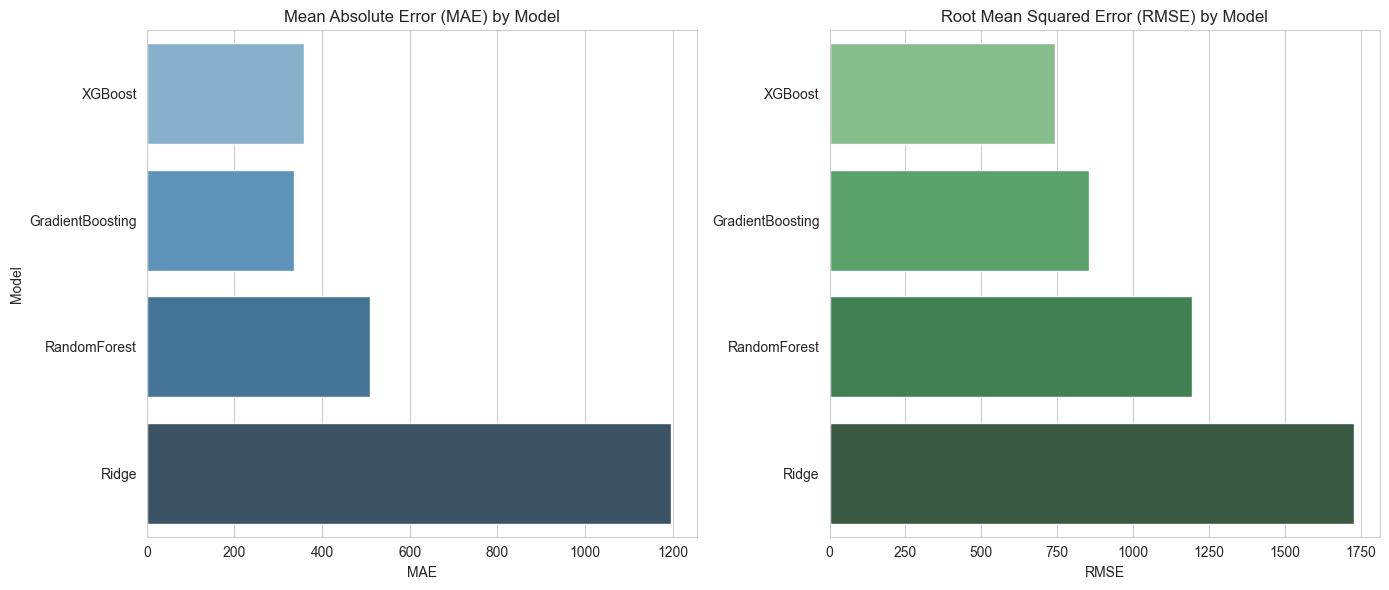

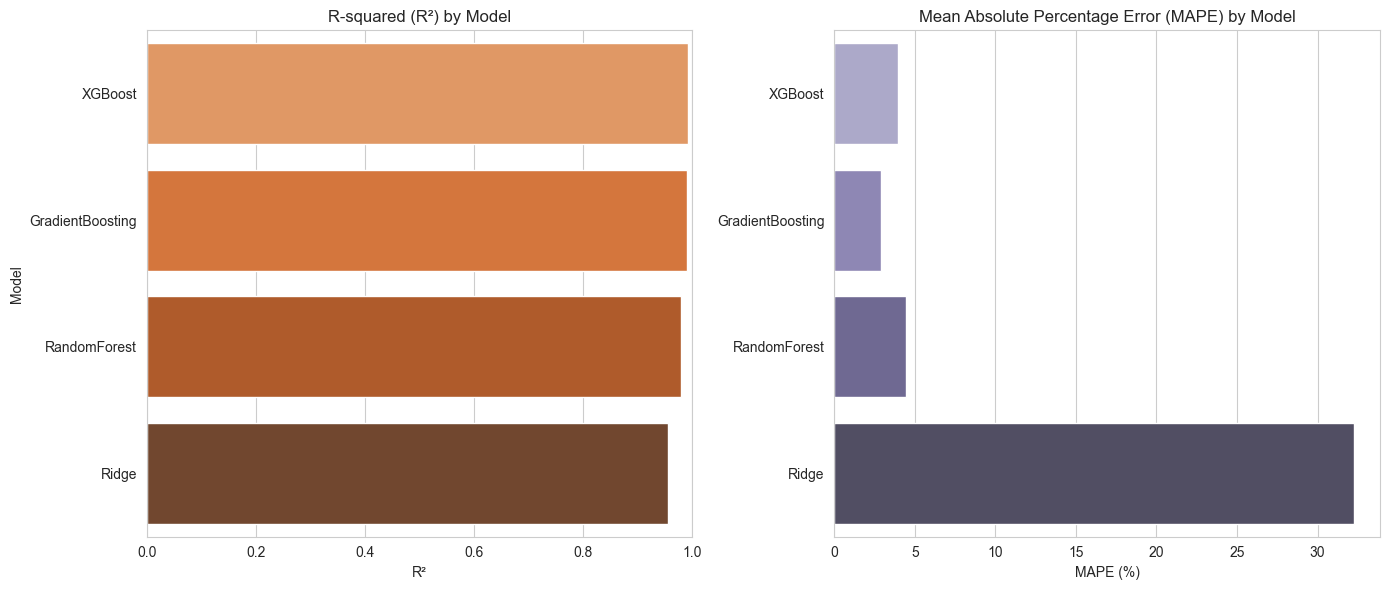

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#  'results'
# results = {
#    'XGBoost': {'MAE': 357.89, 'RMSE': 741.53, 'R2': 0.9919, 'MAPE': 3.97},
#    'RandomForest': {...},
#    'Lasso': {...},
#    'NeuralNet': {...},
# }

# Convert results dict to DataFrame for plotting
metrics_list = []
for model_name, metrics in results.items():
    metrics_list.append({
        'Model': model_name,
        'MAE': metrics.get('MAE', np.nan),
        'RMSE': metrics.get('RMSE', np.nan),
        'R2': metrics.get('R2', np.nan),
        'MAPE': metrics.get('MAPE', np.nan),
    })

df_metrics = pd.DataFrame(metrics_list)

# Sort models by RMSE ascending for clear plots
df_metrics_sorted = df_metrics.sort_values('RMSE')

# Plot MAE and RMSE side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_metrics_sorted, x='MAE', y='Model', ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Absolute Error (MAE) by Model')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Model')

sns.barplot(data=df_metrics_sorted, x='RMSE', y='Model', ax=axes[1], palette='Greens_d')
axes[1].set_title('Root Mean Squared Error (RMSE) by Model')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Plot R2 and MAPE side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_metrics_sorted, x='R2', y='Model', ax=axes[0], palette='Oranges_d')
axes[0].set_title('R-squared (R²) by Model')
axes[0].set_xlabel('R²')
axes[0].set_xlim(0, 1)
axes[0].set_ylabel('Model')

sns.barplot(data=df_metrics_sorted, x='MAPE', y='Model', ax=axes[1], palette='Purples_d')
axes[1].set_title('Mean Absolute Percentage Error (MAPE) by Model')
axes[1].set_xlabel('MAPE (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


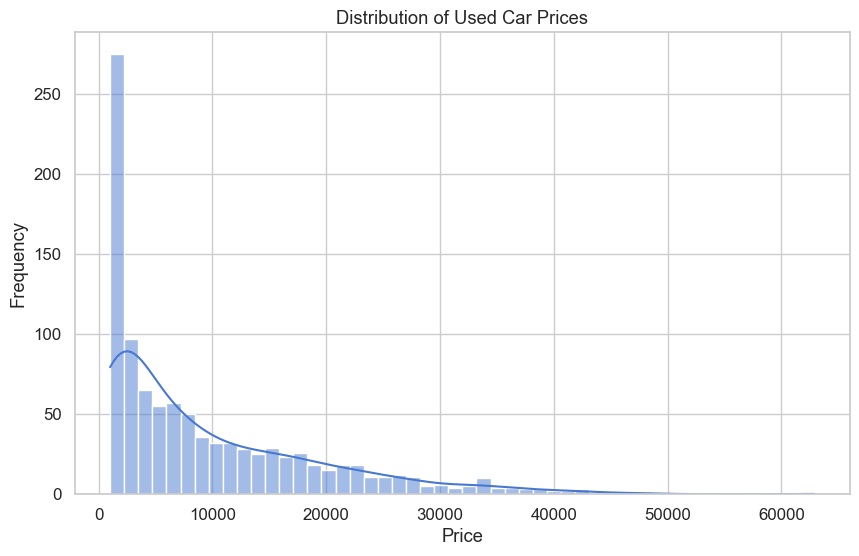

Price skewness: 1.48


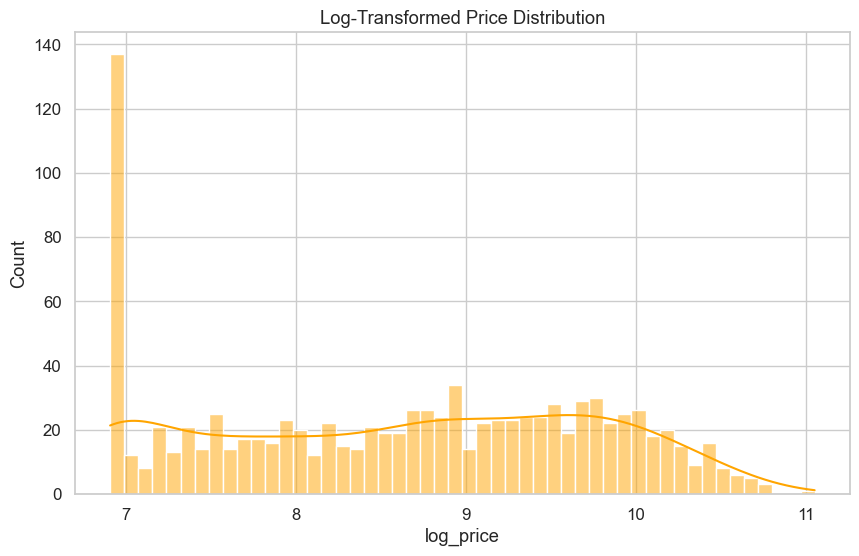

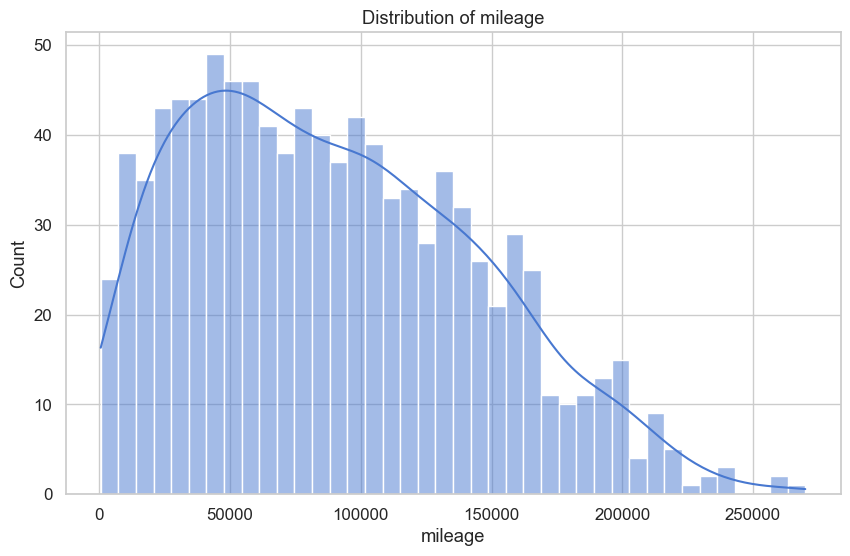

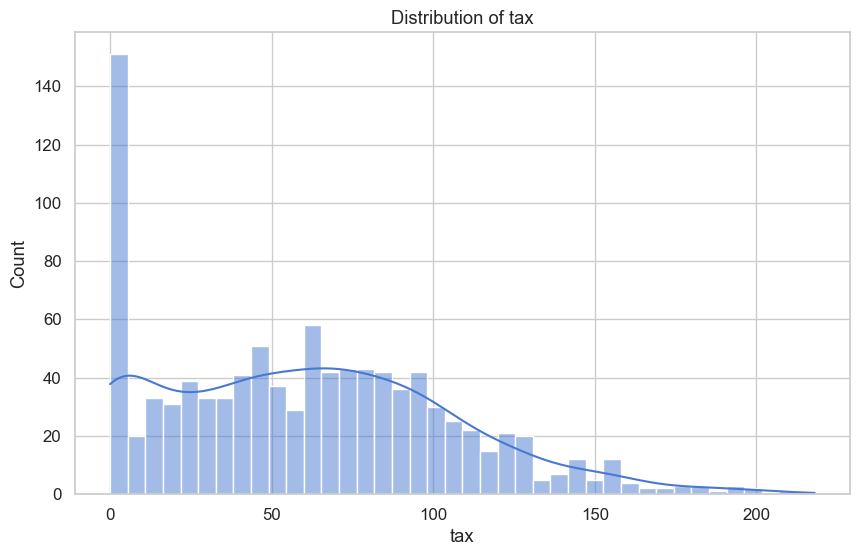

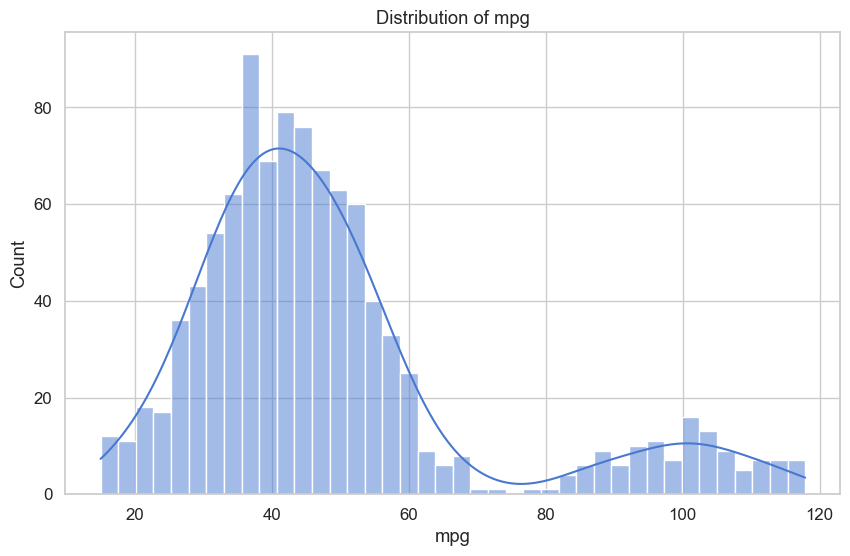

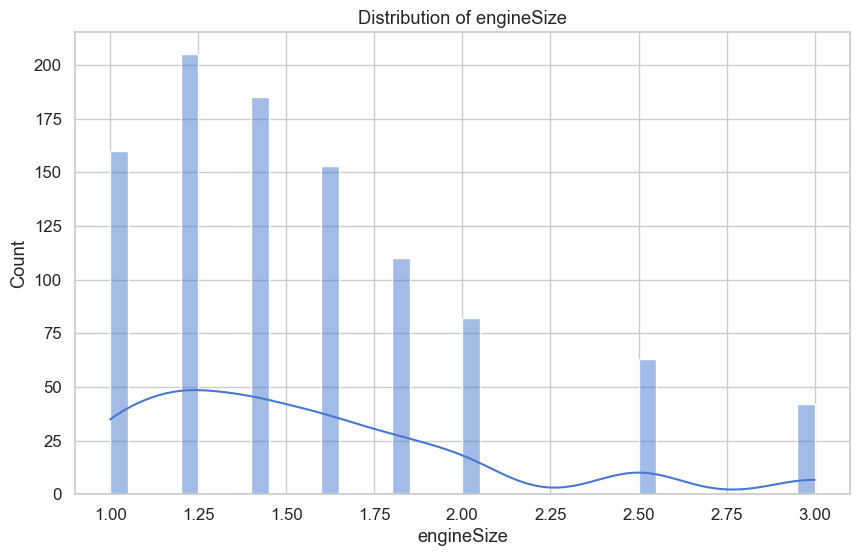

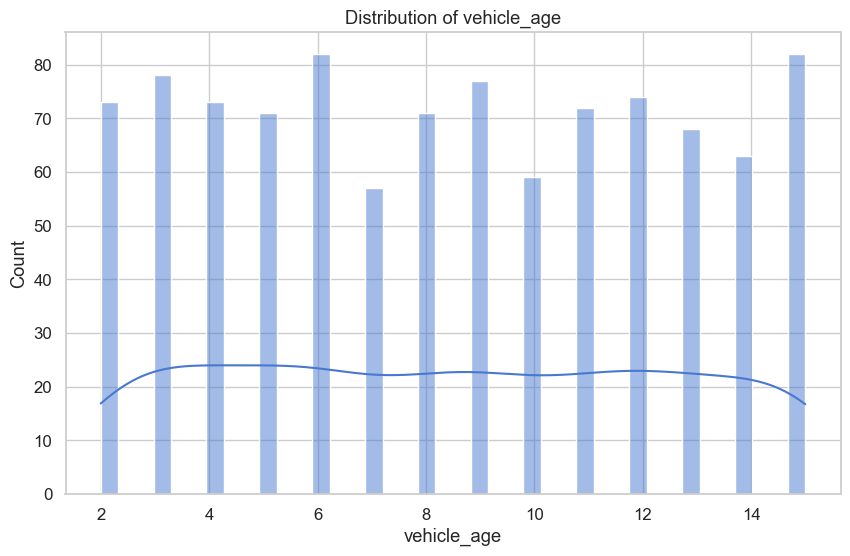

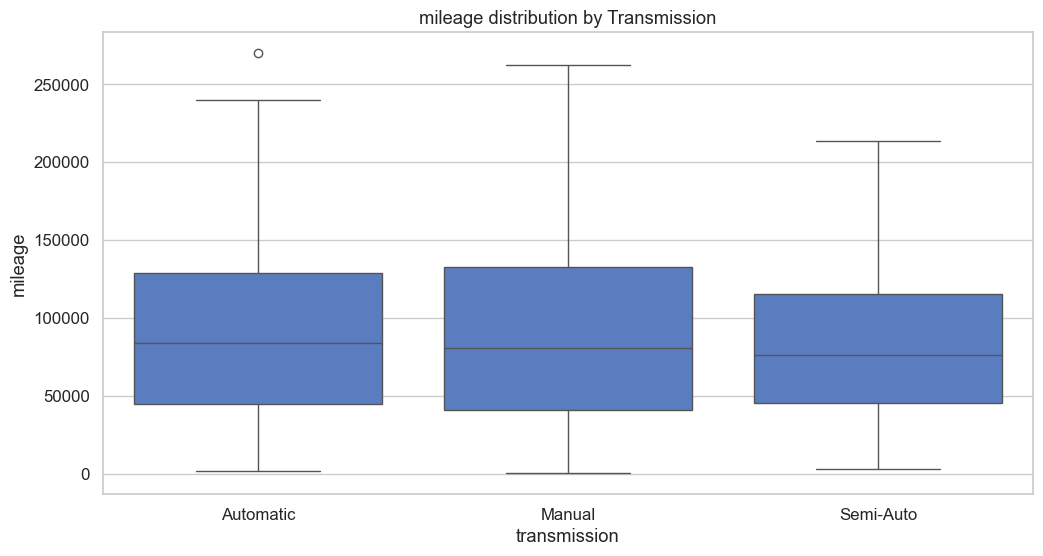

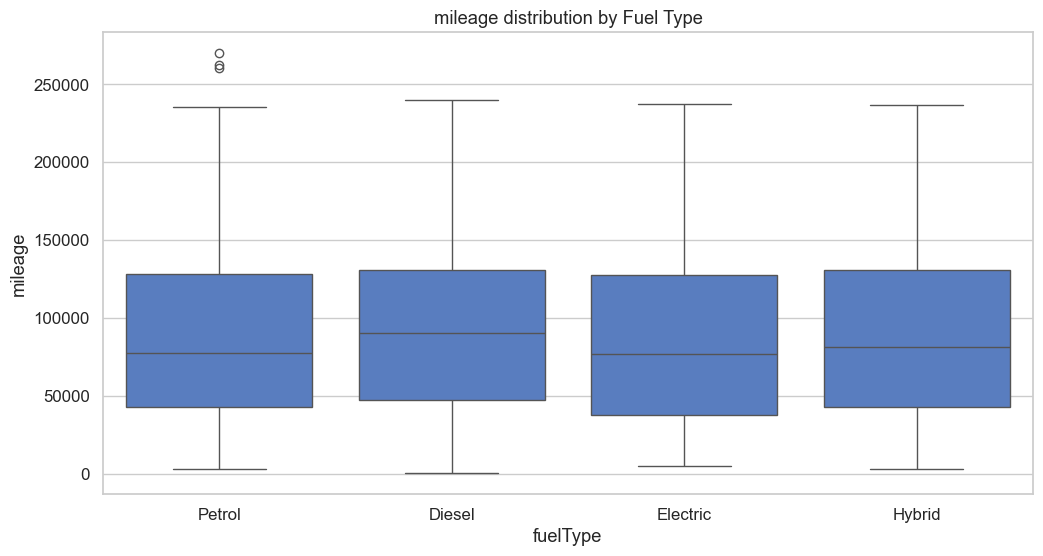

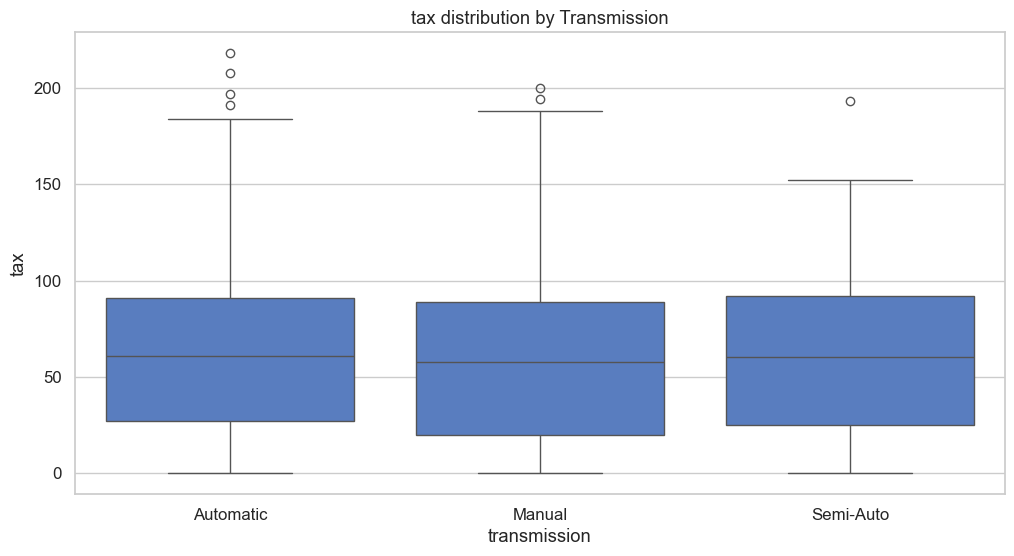

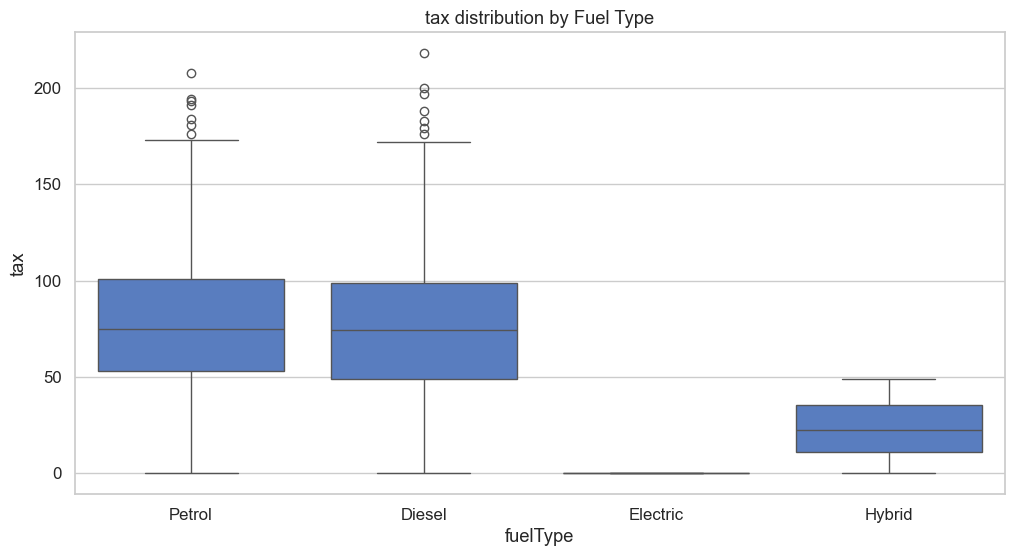

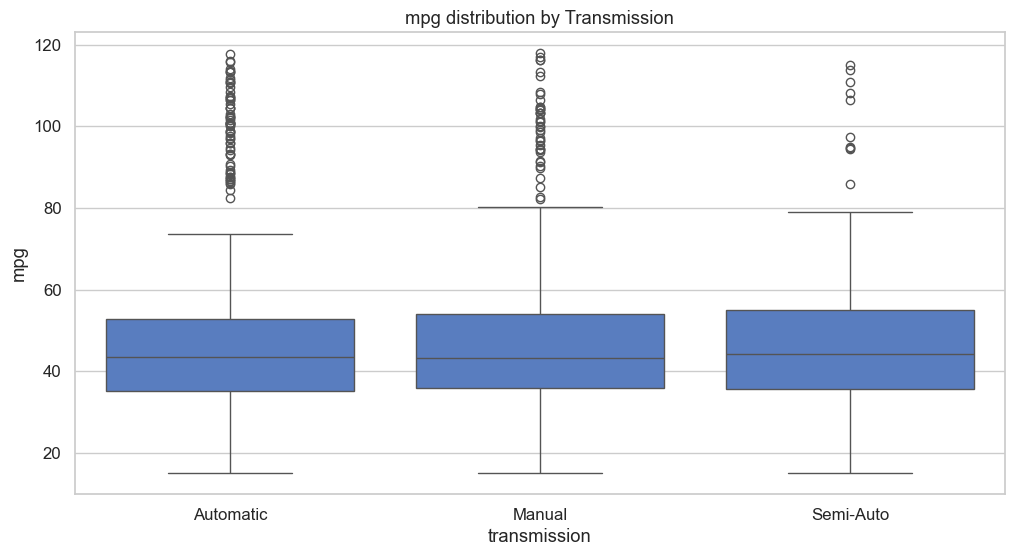

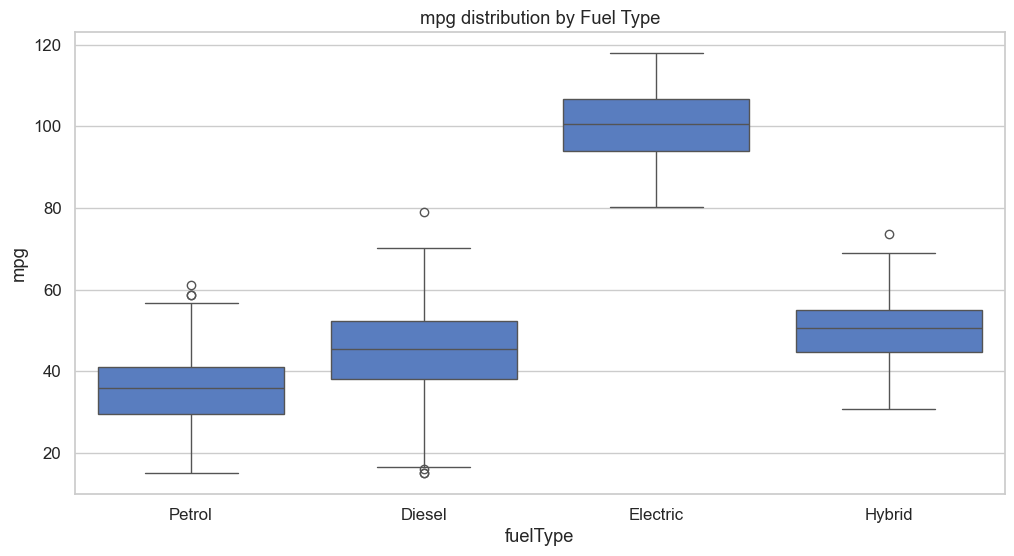

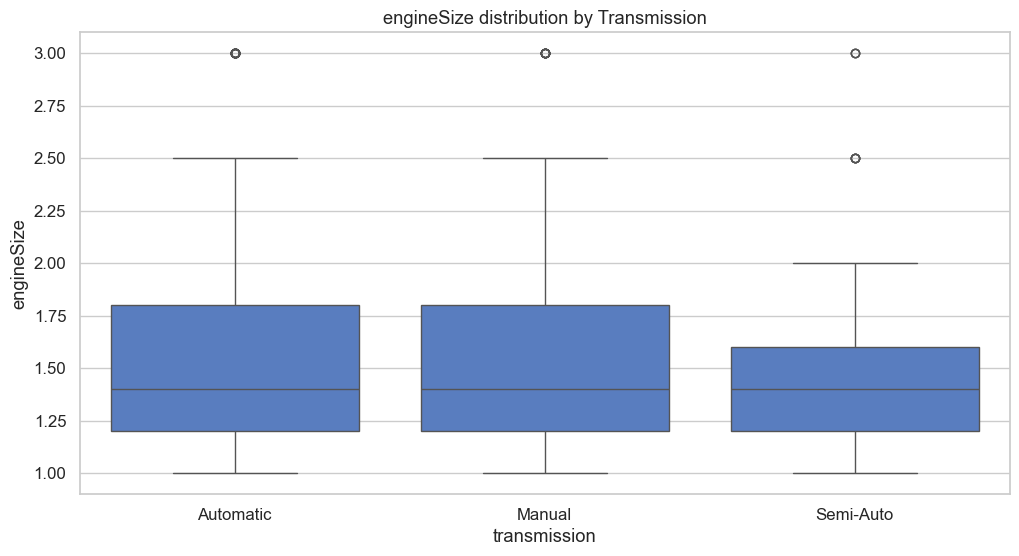

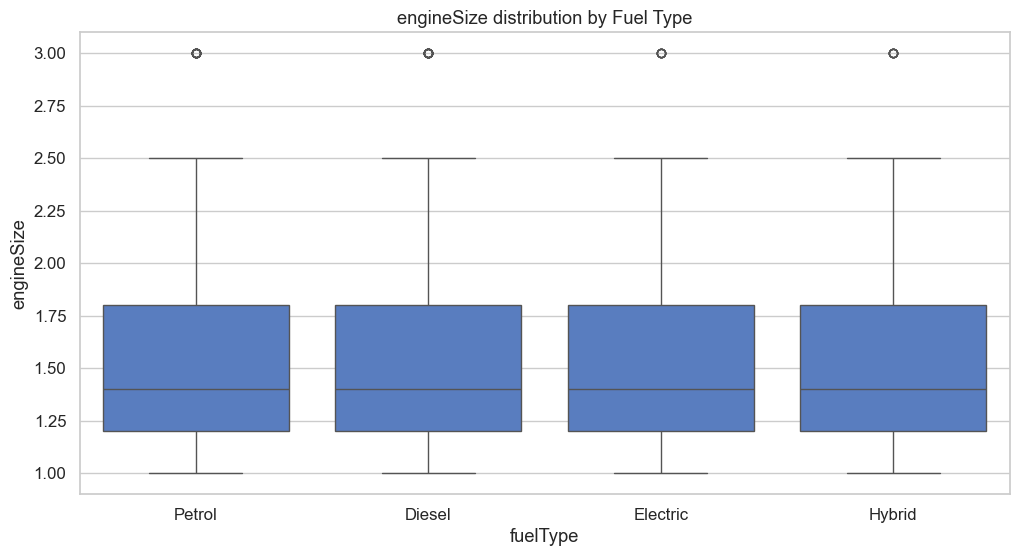

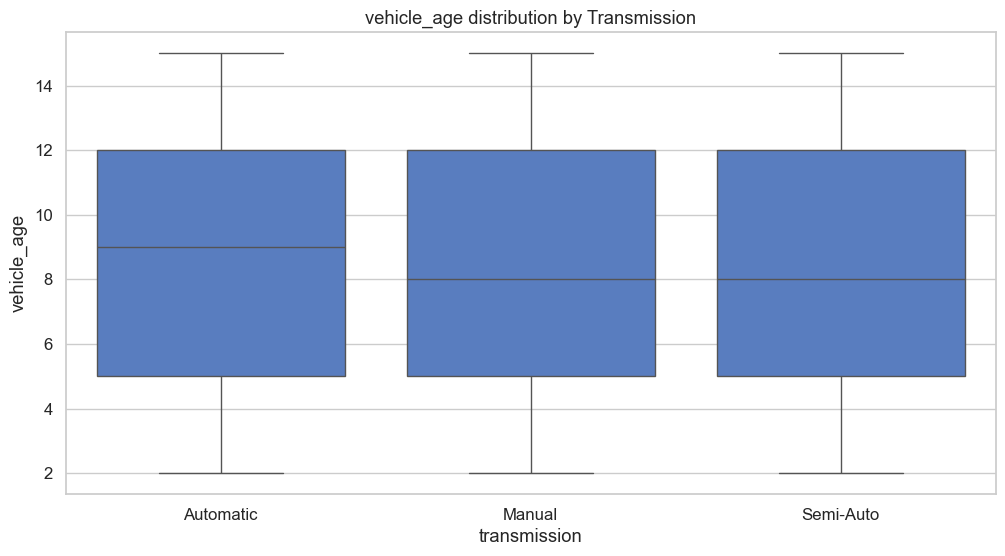

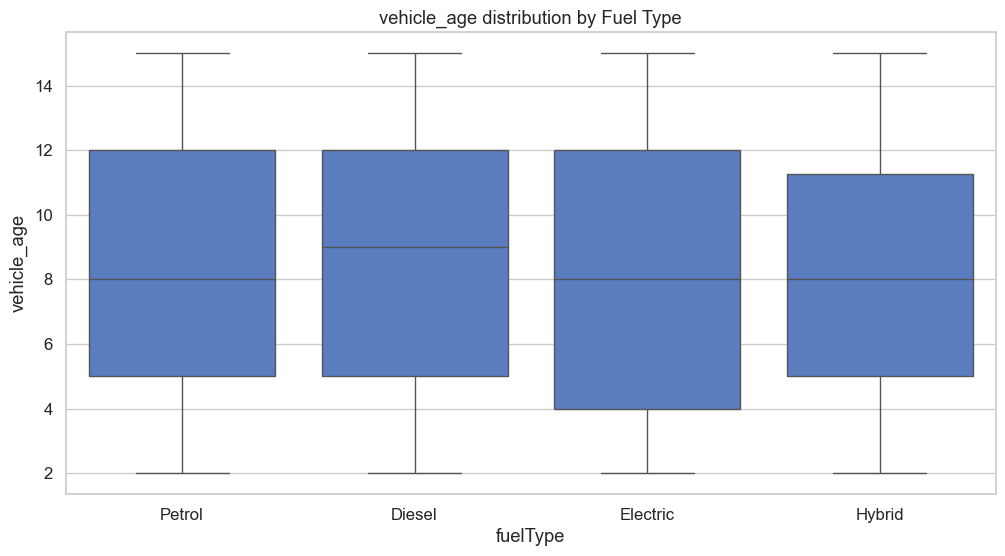

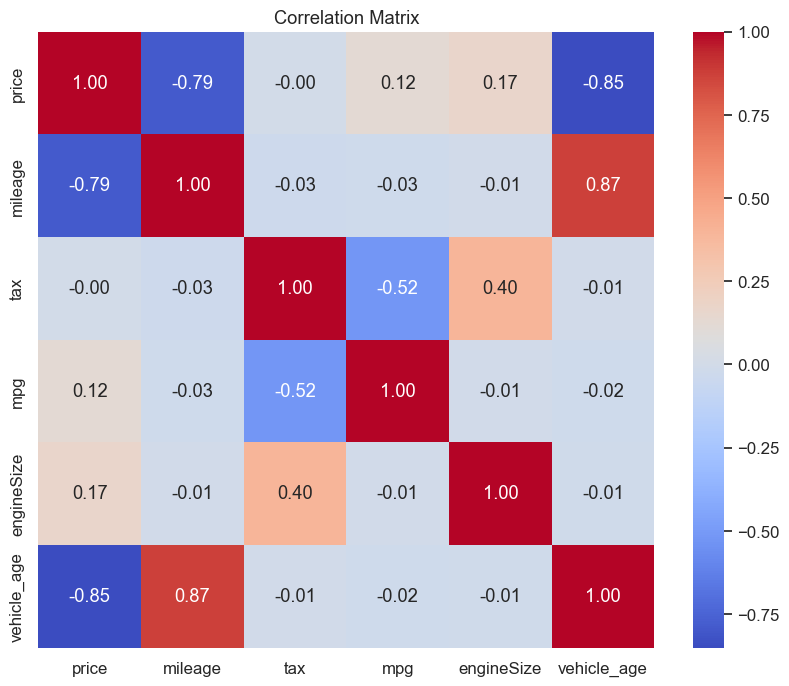

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set plot style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10,6)

# Add vehicle_age column based on current year
current_year = 2025
df['vehicle_age'] = current_year - df['year']


# 3) Distribution of target variable: price
plt.figure()
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Check skewness and log-transform if needed
print(f"Price skewness: {df['price'].skew():.2f}")
if abs(df['price'].skew()) > 1:
    df['log_price'] = np.log1p(df['price'])
    plt.figure()
    sns.histplot(df['log_price'], bins=50, kde=True, color='orange')
    plt.title("Log-Transformed Price Distribution")
    plt.show()

# 4) Numeric feature distributions
num_features = ['mileage', 'tax', 'mpg', 'engineSize', 'vehicle_age']
for feat in num_features:
    plt.figure()
    sns.histplot(df[feat], bins=40, kde=True)
    plt.title(f"Distribution of {feat}")
    plt.xlabel(feat)
    plt.show()

# 5) Boxplots of numeric features grouped by transmission and fuelType
for feat in num_features:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df, x='transmission', y=feat)
    plt.title(f"{feat} distribution by Transmission")
    plt.show()
    
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df, x='fuelType', y=feat)
    plt.title(f"{feat} distribution by Fuel Type")
    plt.show()

# 6) Correlation matrix heatmap (numerical + price)
plt.figure(figsize=(10,8))
corr = df[['price'] + num_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()
